<div dir="rtl">

# 🎓 معمل رؤية الكمبيوتر: التعامل مع الصور


</div>

<div dir="rtl">

# 🖼️ كيف يرى الكمبيوتر صورنا؟ (المصفوفات الرقمية)

تخيل أنك تنظر إلى صورة حصان جميلة.. أنت ترى شعراً وعيوناً، لكن الكمبيوتر يرى **فسيفساء عملاقة** من المربعات الصغيرة تسمى **بكسلات (Pixels)**. 

كل بكسل له **رقم** يمثل شدة الضوء:
*   **0** يعني أسود (مطفأ).
*   **255** يعني أبيض (سوبر مشرق).

المصفوفة (Array) هي مجرد جدول لهذه الأرقام، تماماً مثل جداول Excel.

**مثال لجدول 3×3 بكسل:**

| 255 | 0 | 255 |
| :---: | :---: | :---: |
| 0 | 255 | 0 |
| 255 | 0 | 255 |


</div>

In [ ]:
import sys
if 'google.colab' in sys.modules:
    %pip install numpy Pillow
else:
    !pip install numpy Pillow


In [2]:
import numpy as np  # numpy==1.26.4
from PIL import Image  # Pillow==10.2.0
import os
import requests


<div dir="rtl">

## 1. قراءة وعرض الصور 📥
أول خطوة هي إدخال الصورة إلى لغة البرمجة. فكر فيها كأننا نأخذ صورة فوتوغرافية ونضعها داخل "ماسح ضوئي" برمجياً ليفهمها الكمبيوتر.


</div>

<div dir="rtl">

للتعامل مع الصور برمجياً، نمر بخطوتين بسيطتين:
1. 📥 **التحميل:** نستخدم `Image.open()` لفتح ملف الصورة.
2. 🔢 **التحويل:** نستخدم `np.asarray()` لتحويل تلك الصورة إلى أرقام (مصفوفة) لكي يتمكن الكمبيوتر من معالجتها.


</div>

In [ ]:
import os
import requests
image_file_path = "horse.png"
# Download the image if it doesn't exist (e.g. in Colab)
if not os.path.exists(image_file_path):
    url = "https://raw.githubusercontent.com/NaifMersal/cv-for-developers-ultralytics/main/slides/assets/horse.png"
    r = requests.get(url)
    with open(image_file_path, "wb") as f:
        f.write(r.content)
img = Image.open(image_file_path)
arr = np.asarray(img)

<div dir="rtl">

لعرض الصورة بعد تحويلها لمصفوفة، نحتاج لتحويل الأرقام مرة أخرى إلى هيئة صورة باستخدام `PIL.Image.fromarray()`.


</div>

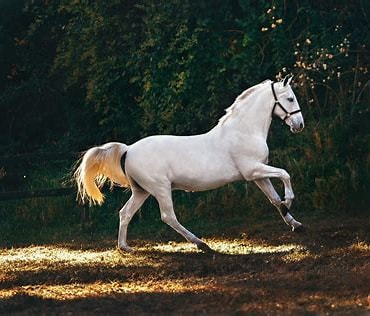

In [86]:
Image.fromarray(arr)

<div dir="rtl">

## 2. الحقيقة الرقمية: الصور هي مصفوفات! 🔢
هنا تبدأ المتعة! عندما نقول "مصفوفة"، فنحن نقصد "جدول أرقام". 

> [!TIP]
> **فكر فيها كذا:** الصورة الملونة هي عبارة عن 3 جداول فوق بعضها (أحمر، أخضر، أزرق). كل مربع في الجدول يسمى **بكسل (Pixel)**.


</div>

<div dir="rtl">

لنستخرج أبعاد الصورة (الارتفاع، العرض، وعدد قنوات الألوان) ونوع البيانات.


</div>

In [87]:
arr.shape

(316, 370, 3)

In [88]:
dict(
    zip(["height", "width", "channels"], arr.shape)
)  # هنا نستخدم سحر بايثون لدمج العناوين مع الأرقام في قاموس (Dictionary) ليسهل قراءتها!

{'height': 316, 'width': 370, 'channels': 3}

In [89]:
arr.dtype

dtype('uint8')

<div dir="rtl">

### 🧐 ماذا يعني uint8؟

**الحرف U**
يعني Unsigned (بدون إشارة).
الفرق: الأرقام العادية تقبل السالب والموجب، أما هنا فالأرقام دائماً موجبة (تبدأ من الصفر).

**المصطلح INT**
يعني Integer (رقم صحيح).
هذا يعني أن ألوان الصور لا تحتوي على فواصل عشرية.

**الرقم 8**
يعني 8-بت (حجم الصندوق).
هذا الصندوق يتسع لـ 256 درجة لونية فقط.

**النتيجة النهائية**
الأرقام في الصور تبدأ من 0 (أسود) إلى 255 (أبيض).


</div>

In [90]:
arr.min(), arr.max()

(np.uint8(0), np.uint8(255))

<div dir="rtl">

يمكننا الحصول على قيم الألوان لأي بكسل عن طريق تحديد إحداثياته في المصفوفة.


</div>

In [91]:
y, x = 84, 265

arr[y, x]

array([248, 247, 245], dtype=uint8)

In [92]:
dict(zip("RGB", arr[y, x]))  # هنا نستخدم سحر بايثون لدمج العناوين مع الأرقام في قاموس (Dictionary) ليسهل قراءتها!

{'R': np.uint8(248), 'G': np.uint8(247), 'B': np.uint8(245)}

<div dir="rtl">

## 3. صيد البكسلات: الوصول لأي نقطة وتغييرها 🎯
كل بكسل في الصورة له "عنوان" مثل إحداثيات الخريطة (رقم الصف، رقم العمود). إذا عرفت العنوان، يمكنك تغيير لون هذه النقطة!


</div>

<div dir="rtl">

يبدو أن هذا اللون قريب من الأبيض (على جسم الحصان). دعونا نغير لونه للأحمر. سنقوم بنسخ الصورة أولاً لتجنب تعديل الأصل.


</div>

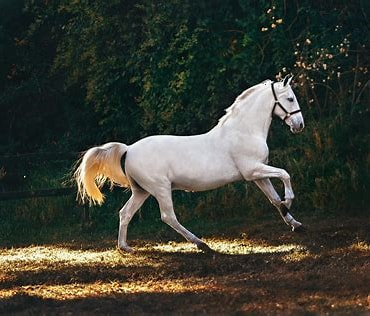

In [93]:
arr = arr.copy()
arr[y, x] = (255, 0, 0)

Image.fromarray(arr)

<div dir="rtl">

هل تلاحظ النقطة الحمراء الصغيرة جداً؟ هذا بكسل واحد فقط. لنجعل الأمر أوضح برسم مربع بمساحة 20×20 بكسل باللون الأحمر.


</div>

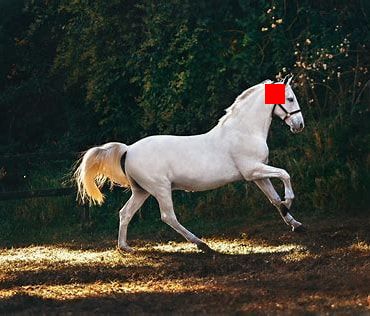

In [94]:
arr[y : y + 20, x : x + 20] = (255, 0, 0)  # we are benefiting from broadcasting here

Image.fromarray(arr)

<div dir="rtl">

## 4. فن القص واللصق ✂️
تماماً كما تفعل في برامج تعديل الصور، يمكنك قص "شريحة" من أرقام المصفوفة ولصقها في مكان آخر.


</div>

<div dir="rtl">

بإمكاننا قص أي جزء من الصورة كما نشاء عبر عملية تسمى "التقطيع" (Slicing). 
فكر فيها كأنك تحدد منطقة معينة في جدول بيانات لتنسخها.


</div>

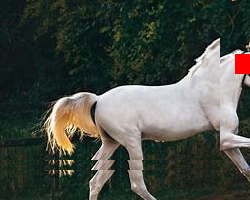

In [69]:
top, left = 30, 30
height, width = 200, 250

crop = arr[top : top + height, left : left + width]
Image.fromarray(crop)

<div dir="rtl">

لنقم بلصق هذا الجزء المقصوص في الركن العلوي الأيسر من الصورة.


</div>

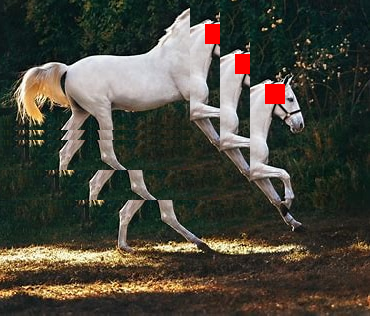

In [95]:
y, x = 0, 0

arr[y : y + height, x : x + width] = crop

Image.fromarray(arr)

<div dir="rtl">

### 5. قلب الصورة (Flip)


</div>

<div dir="rtl">

لنقم بقلب الصورة رأسياً (من الأعلى للأسفل).


</div>

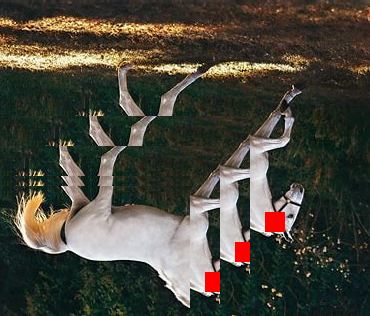

In [96]:
Image.fromarray(arr[::-1])

<div dir="rtl">

أو من اليسار لليمين.


</div>

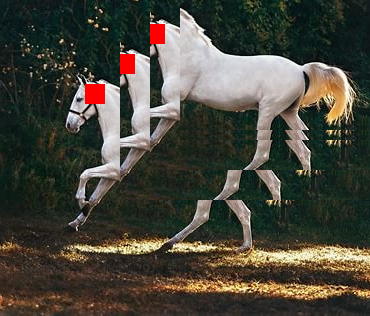

In [97]:
Image.fromarray(arr[:, ::-1])

<div dir="rtl">

## 6. عكس الألوان (Negative Image)


</div>

<div dir="rtl">

لنستخرج الصورة المعكوسة (مثل ما نراه في أفلام الكاميرات القديمة).


</div>

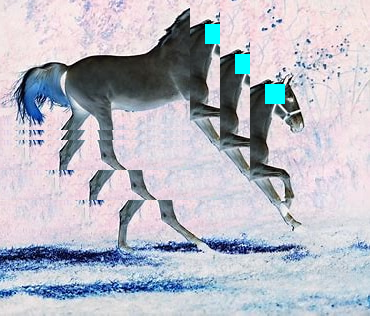

In [98]:
Image.fromarray(~arr)

<div dir="rtl">

تمرين ممتع: إذا حدقت في المربع الأزرق لمدة دقيقة أو دقيقتين، ثم نظرت بسرعة لخلفية بيضاء (جدار مثلاً) ورمشت بعينيك، سترى 'خيالاً' للصورة بألوانها الأصلية.


</div>

<div dir="rtl">

## 7. تفكيك الصورة: قنوات الألوان (RGB) 🌈
أي صورة ملونة هي في الأصل مزيج من 3 ألوان أساسية. سنقوم هنا بـ "تشريح" الصورة لنرى الطبقات الملونة.


</div>

<div dir="rtl">

يمكننا استخراج قنوات الألوان (الأحمر والأخضر والأزرق) عن طريق تغيير ترتيب المحاور في المصفوفة وفصلها.


</div>

In [ ]:
r = arr[..., 0]
g = arr[..., 1]
b = arr[..., 2]

<div dir="rtl">

لنقم بإزالة اللون الأحمر تماماً من الصورة واستبداله بالأصفار لنرى كيف ستتغير النتيجة.


</div>

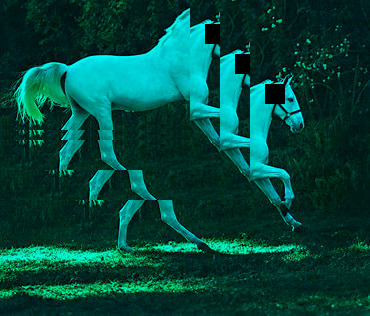

In [101]:
Image.fromarray(np.stack([r * 0, g, b], axis=-1))

<div dir="rtl">

لاحظ كيف تحولت المربعات الحمراء إلى سوداء، واختفت نغمة اللون الأحمر من الصورة تماماً.


</div>

<div dir="rtl">

## 8. تحويل الصورة للأبيض والأسود


</div>

<div dir="rtl">

لاحظ أننا نقسم على 3 لنأخذ "المتوسط الحسابي" للألوان. 
> [!TIP]
> **لماذا نحول النوع لـ float؟** لأن جمع ثلاثة أرقام قد يتجاوز الرقم 255، مما يسبب "فيضان" (Overflow) في الذاكرة وتظهر الألوان بشكل خاطئ!


</div>

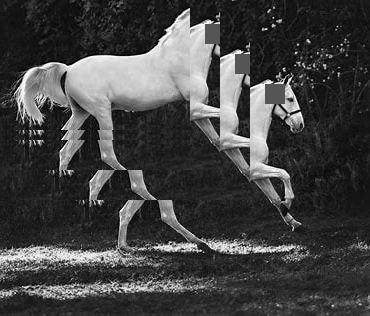

In [102]:
gray = (r / 3 + g / 3 + b / 3).astype("uint8")
Image.fromarray(gray)

<div dir="rtl">

## 👁️ خدعة العين البشرية!
هل تعلم أن عينك ترى اللون الأخضر بوضوح أكثر من الأزرق؟ لذلك، في رؤية الكمبيوتر، نعطي "وزناً" أكبر للون الأخضر (58%) عند التحويل للأبيض والأسود لتبدو الصورة طبيعية أكثر لعينك.


</div>

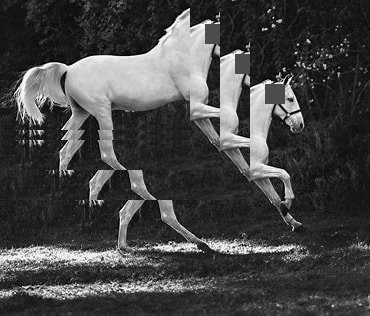

In [103]:
gray = (r * 0.299 + g * 0.587 + b * 0.114).astype("uint8")
Image.fromarray(gray)

<div dir="rtl">

## 9. التمييز الذكي (Thresholding) 🔍
هذه الخطوة هي بداية "الذكاء". نحن نخبر الكمبيوتر: "أي رقم أكبر من 150 اعتبره (حصان) وأي رقم أصغر اعتبره (خلفية)".


</div>

<div dir="rtl">

لنقم بتجربة مثيرة: سنعزل الحصان عن الخلفية باستخدام 'شرط منطقي'. أي بكسل إضاءته أعلى من درجة معينة سنعتبره هو هدفنا.


</div>

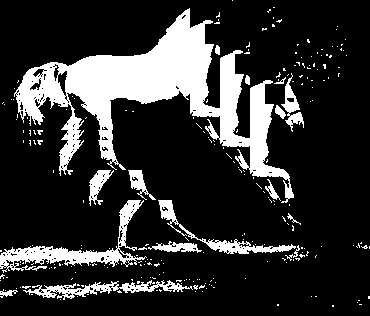

In [105]:
threshold = 128

mask = gray > threshold
Image.fromarray(mask)

<div dir="rtl">

لنستخدم هذا 'القناع' (Mask) لإخفاء كل شيء في الصورة الأصلية ما عدا الحصان.


</div>

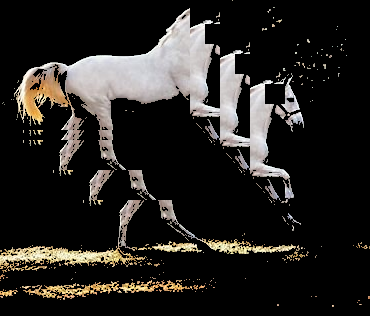

In [107]:
arr[~mask] = 0
Image.fromarray(arr)

<div dir="rtl">

لقد وصلت إلى نهاية هذا المعمل. حان الوقت لتجربة مهاراتك الجديدة في التحديات التالية:

1. **إخفاء المعلومات الحساسة (Image Redaction)**
قم بتحميل صورة تحتوي على معلومات حساسة. قم بقص منطقة مستطيلة تحتوي على النص، ثم استبدلها بمربع أسود.

<details>
<summary>الحل</summary>

```python
# تحميل الصورة
arr = np.array(Image.open('./res/horse.jpg'))

# تحديد إحداثيات المنطقة (مثال)
y, x = 185, 550
height, width = 15, 70

# استبدال المنطقة باللون الأسود (قيمة 0)
arr[y:y + height, x:x + width] = 0

# عرض النتيجة
Image.fromarray(arr).show()
```

</details>

2. **تكرار الصورة (Image Tiling)**
قم بتحميل صورة النمط `tile_pattern.png` وكررها لإنشاء لوحة كبيرة.

<details>
<summary>الحل</summary>

```python
tile = np.asarray(Image.open('./res/tile_pattern.png'))

# تكرار المصفوفة 5 مرات عمودياً ثم 5 مرات أفقياً
canvas = np.concatenate([tile] * 5, axis=0)
canvas = np.concatenate([canvas] * 5, axis=1)

Image.fromarray(canvas).show()
```

</details>

3. **إضافة علامة مائية (Image Watermarking)**
قم بلصق العلامة المائية `watermark.png` في الزاوية اليمنى السفلية من الصورة.

<details>
<summary>الحل</summary>

```python
arr = np.array(Image.open('./res/horse.jpg'))
watermark = np.asarray(Image.open('watermark.png'))

# تحديد منطقة اللصق في الزاوية
crop = arr[-watermark.shape[0]:, -watermark.shape[1]:]

# لصق العلامة المائية مباشرة
crop[...] = watermark 

Image.fromarray(arr).show()
```

</details>

⚠️ تذكر، هناك طرق عديدة للوصول لنفس النتيجة. استمتع بالرحلة! ؛)


</div>